# Visualization Styles

This notebook demonstrates all available styles in `x4c.visual.set_style()`.

Each style is shown with two common geoscience plot types:
- A time series (e.g., global mean temperature anomaly)
- A filled contour / spatial-like plot (using synthetic data)

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import x4c

In [2]:
# --- synthetic data as xr.DataArray ---
np.random.seed(42)

# time series: fake GMST anomaly with trend + variability
years = np.arange(1850, 2025)
time = xr.date_range('1850-01', periods=len(years), freq='YS', calendar='standard', use_cftime=True)
trend = 0.008 * (years - 1850) + 0.0001 * (years - 1850)**1.5
noise = 0.15 * np.random.randn(len(years))

gmst = xr.DataArray(
    trend + noise,
    dims='time', coords={'time': time},
    name='GMST', attrs={'long_name': 'Global Mean Surface Temperature Anomaly', 'units': 'K'},
)

ohc = xr.DataArray(
    0.6 * trend + 0.1 * np.random.randn(len(years)) + 0.3 * np.sin(2 * np.pi * years / 60),
    dims='time', coords={'time': time},
    name='OHC', attrs={'long_name': 'Ocean Heat Content Proxy', 'units': 'K'},
)

# 2-D field: synthetic SST
lon = np.linspace(0, 360, 90)
lat = np.linspace(-90, 90, 45)
LON, LAT = np.meshgrid(lon, lat)
tas_data = (20 * np.cos(np.radians(LAT))
            + 3 * np.sin(np.radians(2 * LON)) * np.cos(np.radians(LAT))
            + np.random.randn(*LAT.shape) * 0.5)

tas = xr.DataArray(
    tas_data,
    dims=('lat', 'lon'), coords={'lat': lat, 'lon': lon},
    name='TAS', attrs={'long_name': 'Surface Temperature', 'units': '°C'},
)

In [3]:
def demo_plots(style_name):
    """Draw a time-series panel and a contour panel for the given style."""
    x4c.visual.set_style(style_name)

    fig, ax = x4c.visual.subplots(
        1, 2, ax_loc={'ts': (0, 0), 'map': (0, 1)},
        projs={'map': 'Robinson'},
        projs_kws={'map': {'central_longitude': 180}},
        figsize=(16, 4),
    )

    # -- time series --
    gmst.x.plot(ax=ax['ts'], label=gmst.attrs['long_name'])
    ohc.x.plot(ax=ax['ts'], label=ohc.attrs['long_name'], alpha=0.8)
    ax['ts'].axhline(0, color='grey', lw=0.8, ls='--')
    ax['ts'].set_xlabel('Year')
    ax['ts'].set_ylabel(f'Anomaly ({gmst.attrs["units"]})')
    ax['ts'].set_title('Global Mean Temperature')
    ax['ts'].legend()

    # -- contour --
    tas.x.plot(ax=ax['map'], levels=20, cmap='RdBu_r')
    ax['map'].set_title(f'{tas.attrs["long_name"]} ({tas.attrs["units"]})')

    x4c.showfig(fig)


## `journal` (default)

Clean style for manuscript figures — Arial font, L-frame spines, dashed grid.

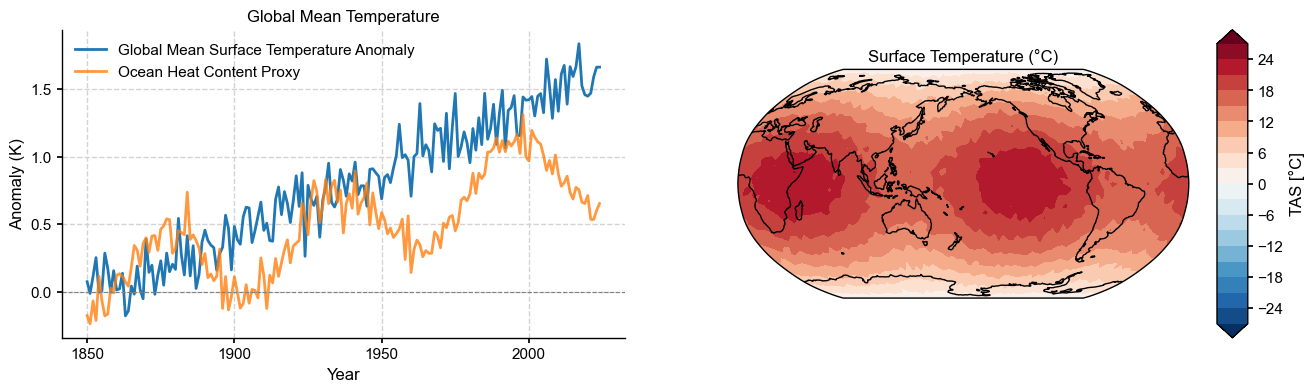

In [4]:
demo_plots('journal')

## `nature`

Compact, publication-ready style inspired by Nature/Science figures.  
Colorblind-safe palette (Wong 2011), inward ticks on all sides, minor ticks visible, no grid.

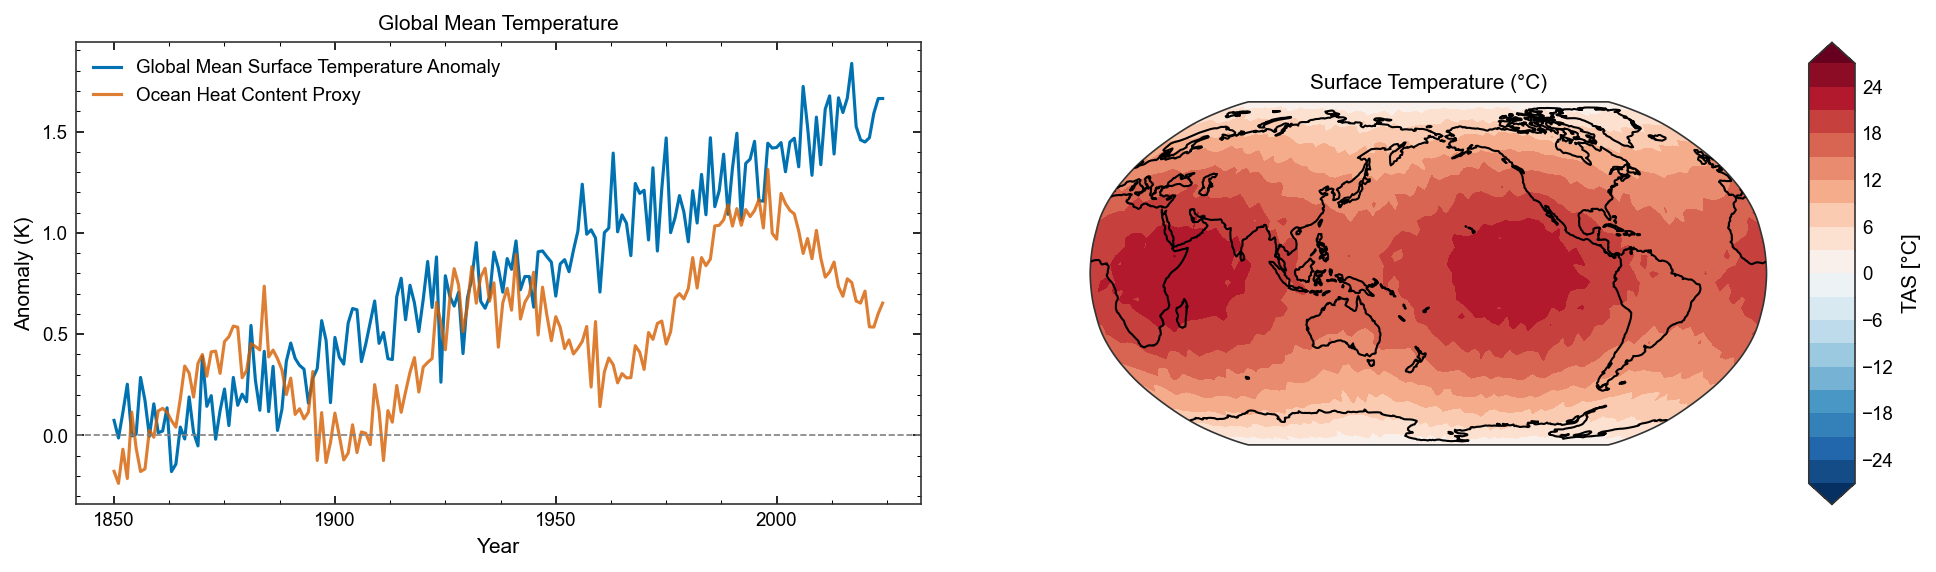

In [5]:
demo_plots('nature')

## `agu`

Style following AGU journal conventions — enclosed axes box, inward ticks with minor ticks,  
framed legend. Grid is off by default; add `_grid` to enable it.

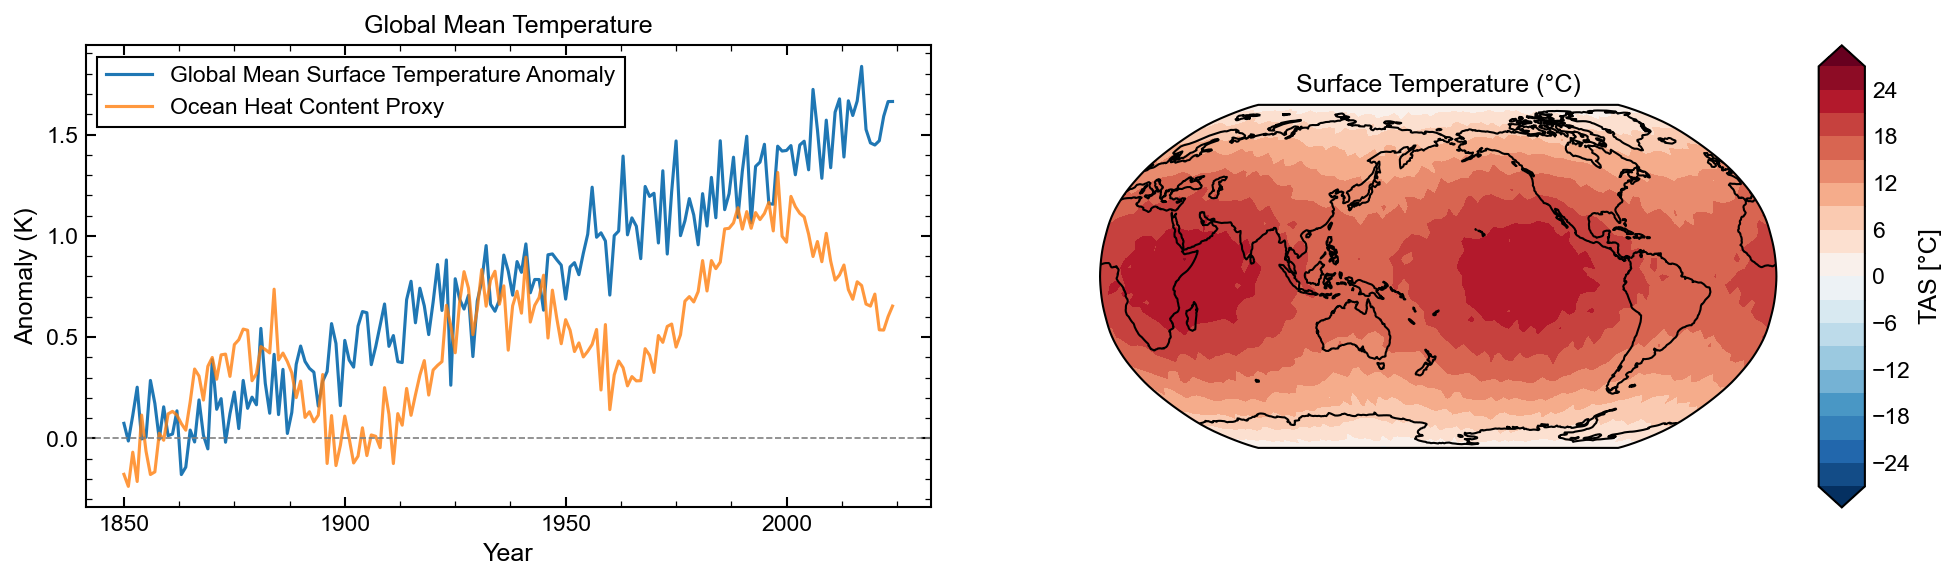

In [6]:
demo_plots('agu')

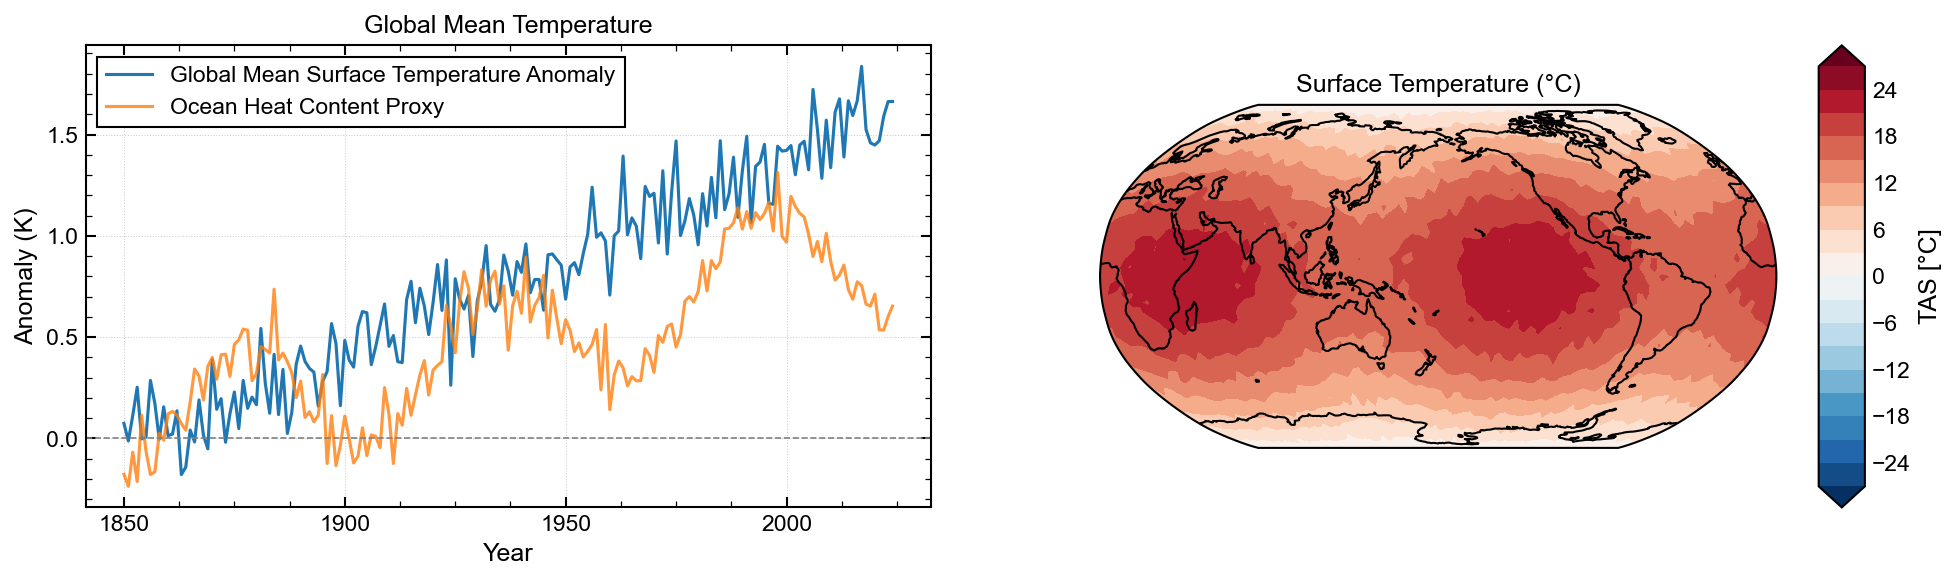

In [7]:
# with grid enabled
demo_plots('agu_grid')

## `presentation`

Bold, high-contrast style for talks and posters — larger fonts, thicker lines, vibrant palette.

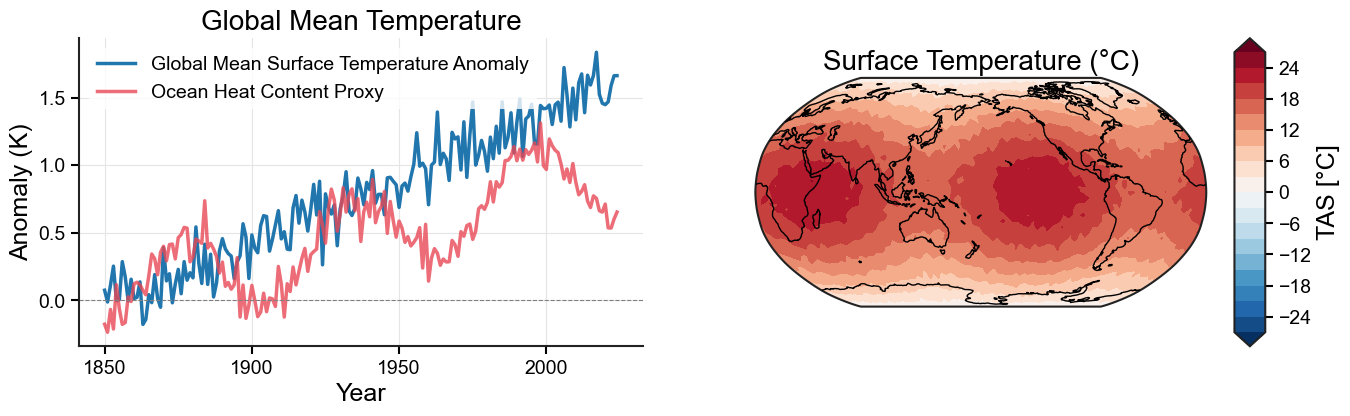

In [8]:
demo_plots('presentation')

## `dark`

Modern dark theme for screen display and dashboards — dark navy background, neon-inspired palette.

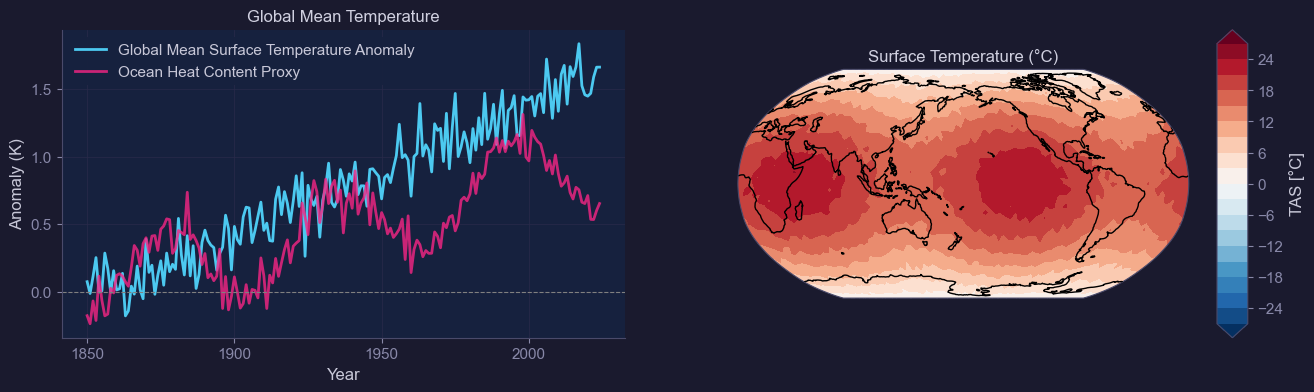

In [9]:
demo_plots('dark')

## `minimal`

Ultra-clean style with thin lines, earth-tone palette, and minimal visual clutter.

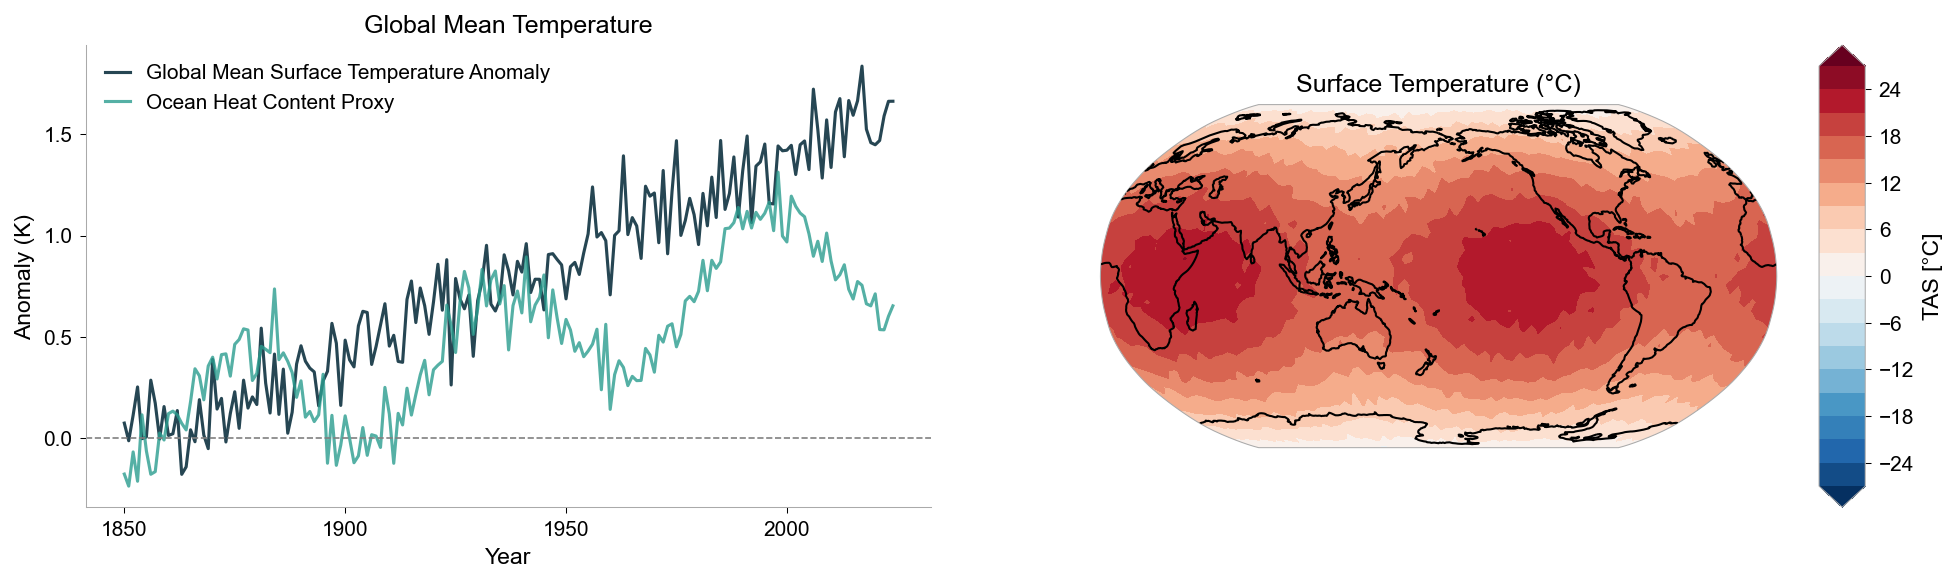

In [10]:
demo_plots('minimal')

## `web`

Web / ggplot-like style — grey text, light background, no spines.

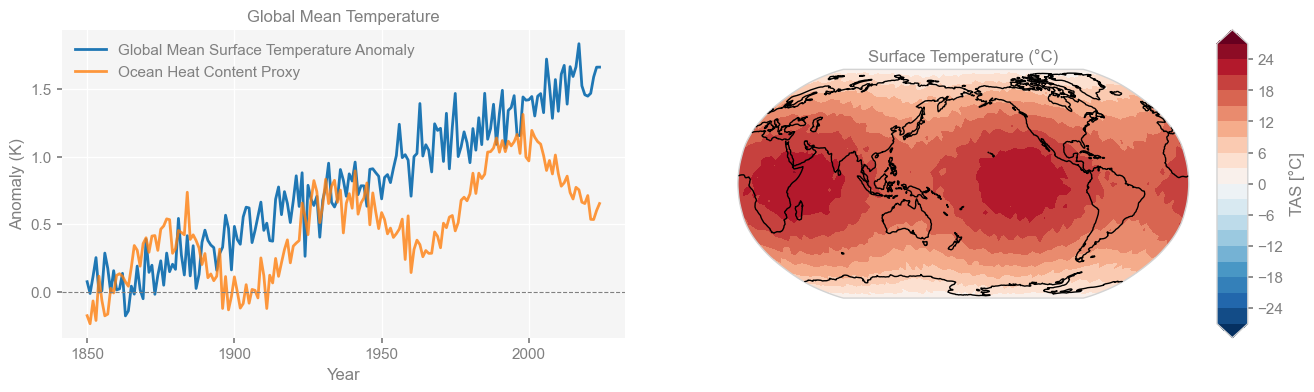

In [11]:
demo_plots('web')

## Modifiers: `_spines`, `_nospines`, `_grid`, `_nogrid`

Any style can be combined with modifiers by appending them to the style name.

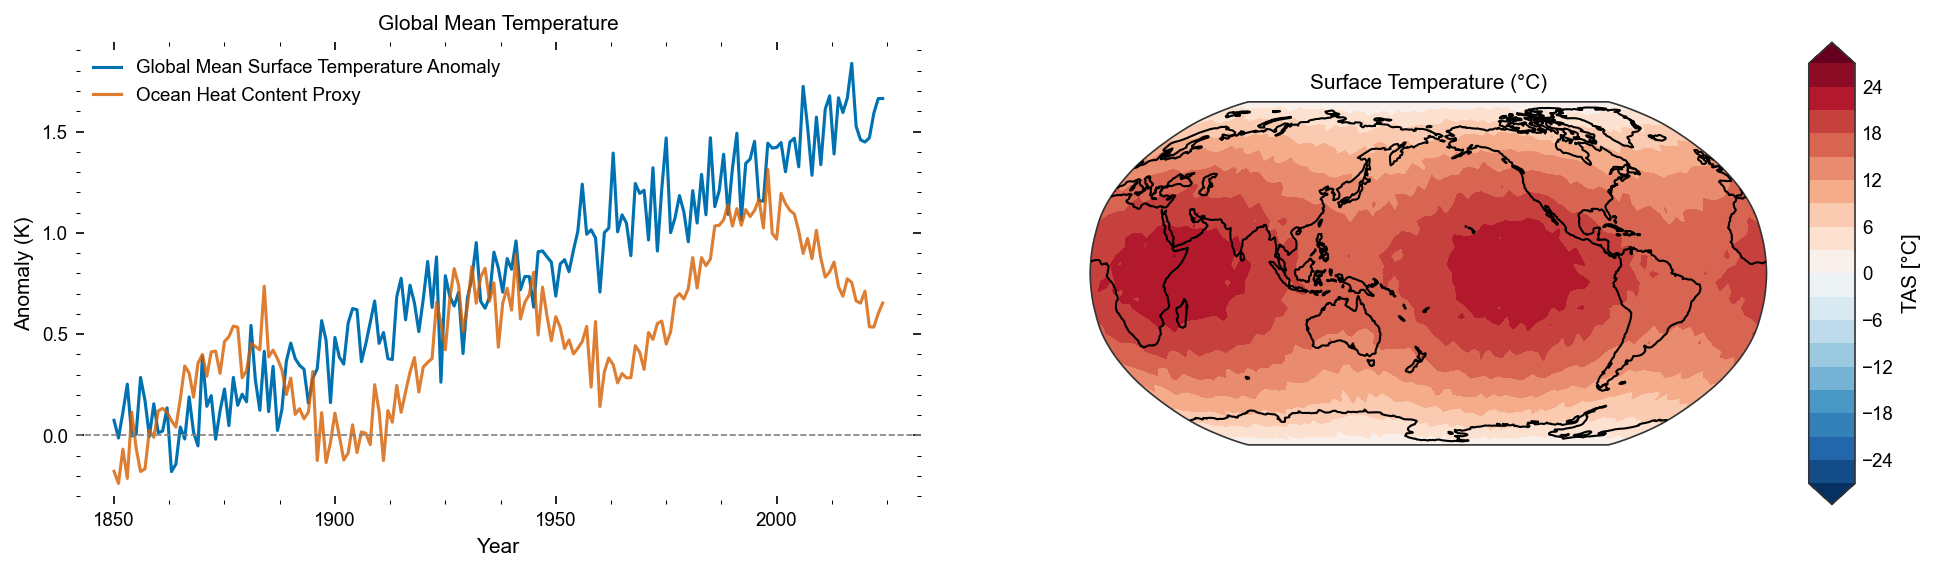

In [12]:
demo_plots('nature_nospines')

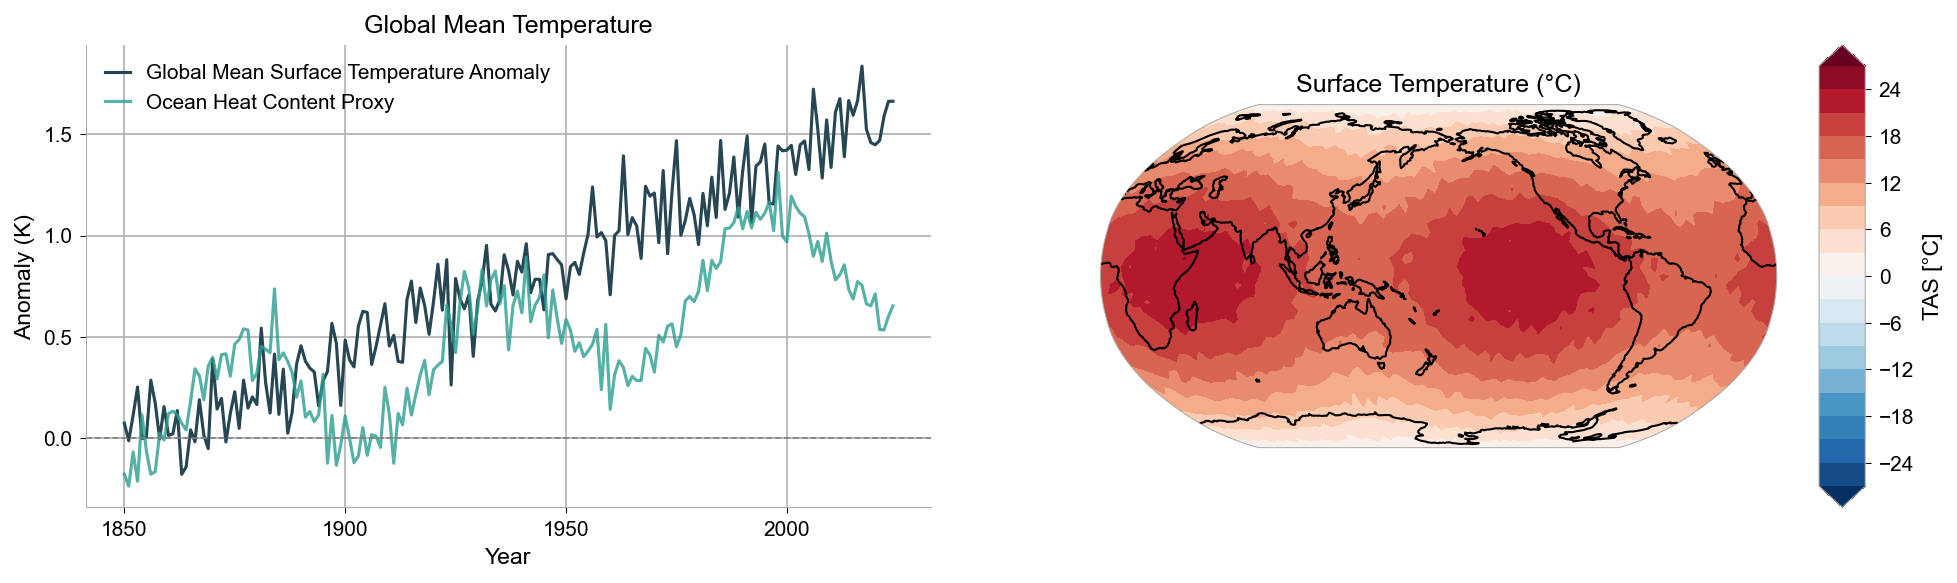

In [13]:
demo_plots('minimal_grid')

## `font_scale`

All styles accept a `font_scale` parameter to uniformly scale font sizes.

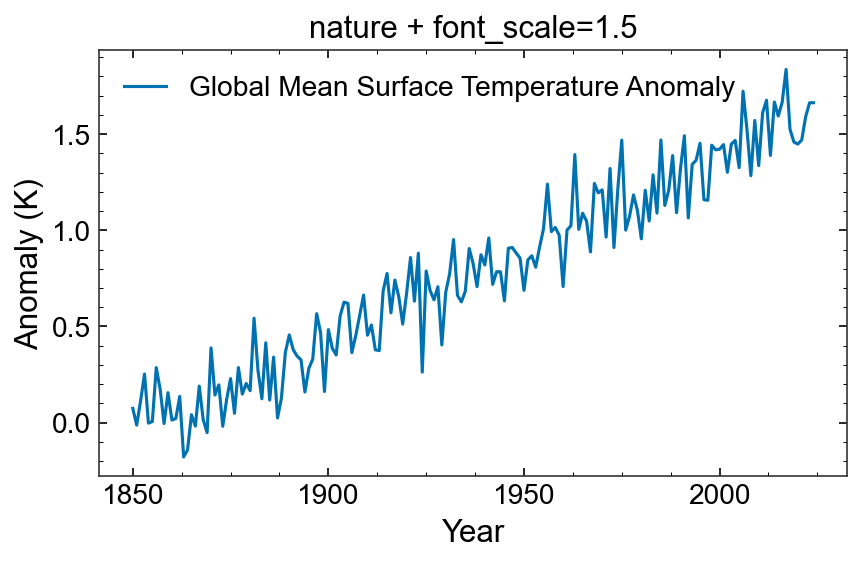

In [14]:
x4c.visual.set_style('nature', font_scale=1.5)

fig, ax = plt.subplots(figsize=(6, 4))
gmst.plot(ax=ax, label=gmst.attrs['long_name'])
ax.set_xlabel('Year')
ax.set_ylabel(f'Anomaly ({gmst.attrs["units"]})')
ax.set_title('nature + font_scale=1.5')
ax.legend()
fig.tight_layout()
plt.show()

In [15]:
# reset to default
x4c.visual.set_style('journal')